In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import sys
sys.path.append('../')

from minilearn.neural_network import ANN as MiniANN
from minilearn.metrics import accuracy_score as mini_accuracy

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC

#load saved data
train_df = pd.read_csv('../data/train_features.csv')
test_df = pd.read_csv('../data/test_features.csv')

#seperate featuer and labels
feature_col = [col for col in train_df.columns if col != 'emotion']

X_train = train_df[feature_col].values
y_train = train_df['emotion'].values

X_test = test_df[feature_col].values
y_test = test_df['emotion'].values

#fix featul label space issue
y_train = np.array([label.strip() for label in y_train])
y_test = np.array([label.strip() for label in y_test])

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Classes: {np.unique(y_train)}")

Training set: (1961, 112)
Test set: (491, 112)
Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [ ]:
#Train mini ANN
print("Training MiniLearn ANN")
mini_ann = MiniANN(hidden_size=128, learning_rate=0.01, n_iterations=1000)
mini_ann.fit(X_train, y_train)

#Evalaute
mini_ann_preds = mini_ann.predict(X_test)
mini_ann_acc = accuracy_score(y_test, mini_ann_preds)
mini_ann_Macc = mini_accuracy(y_test, mini_ann_preds)
print(f'\nMiniLearn ANN Test Accuracy: {mini_ann_acc:.4f}')
print(f'\nMiniLearn ANN Test MiniAccuracy: {mini_ann_Macc:.4f}')


Training MiniLearn ANN
Iteration 100/1000 | Loss: 2.0597
Iteration 200/1000 | Loss: 2.0371
Iteration 300/1000 | Loss: 2.0018
Iteration 400/1000 | Loss: 1.9427
Iteration 500/1000 | Loss: 1.8625
Iteration 600/1000 | Loss: 1.7871
Iteration 700/1000 | Loss: 1.7286
Iteration 800/1000 | Loss: 1.6813
Iteration 900/1000 | Loss: 1.6399
Iteration 1000/1000 | Loss: 1.6017

MiniLearn ANN Test Accuracy: 0.3910

MiniLearn ANN Test MiniAccuracy: 0.3910


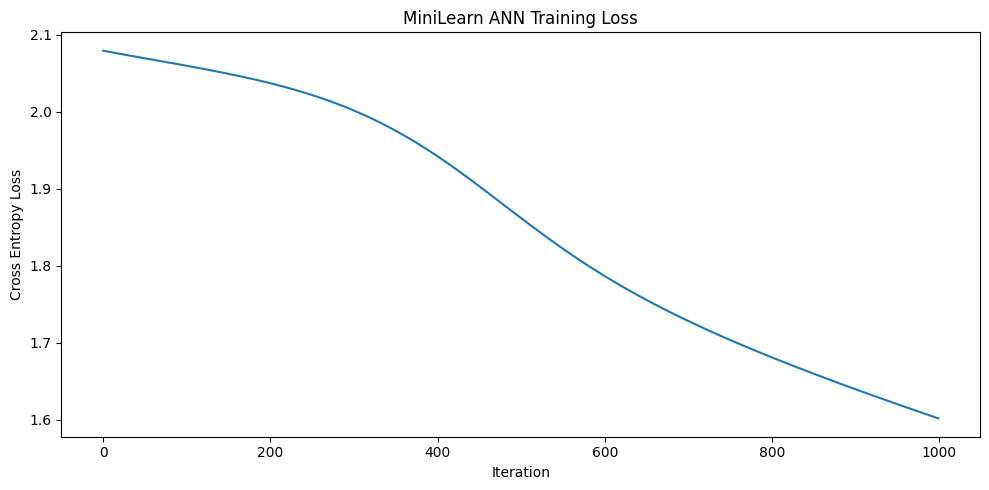

In [3]:
#plotting this ^
plt.figure(figsize=(10,5))
plt.plot(mini_ann.loss_history)
plt.title('MiniLearn ANN Training Loss')
plt.xlabel('Iteration')
plt.ylabel('Cross Entropy Loss')
plt.tight_layout()
plt.show()


In [6]:
#Try training with more iterations see if accuracy increases
print('Training MiniLearn ANN 2000 Iterations')
mini_ann2 = MiniANN(hidden_size=256, learning_rate=0.01, n_iterations=2000)
mini_ann2.fit(X_train, y_train)

mini_ann2_preds = mini_ann2.predict(X_test)
mini_ann2_acc = mini_accuracy(y_test, mini_ann2_preds)
print(f'\nMiniLearn ANN 2000 iter Test Accuracy: {mini_ann2_acc:.4f}')


Training MiniLearn ANN 2000 Iterations
Iteration 100/2000 | Loss: 2.0476
Iteration 200/2000 | Loss: 2.0090
Iteration 300/2000 | Loss: 1.9488
Iteration 400/2000 | Loss: 1.8659
Iteration 500/2000 | Loss: 1.7851
Iteration 600/2000 | Loss: 1.7219
Iteration 700/2000 | Loss: 1.6709
Iteration 800/2000 | Loss: 1.6260
Iteration 900/2000 | Loss: 1.5844
Iteration 1000/2000 | Loss: 1.5444
Iteration 1100/2000 | Loss: 1.5053
Iteration 1200/2000 | Loss: 1.4664
Iteration 1300/2000 | Loss: 1.4278
Iteration 1400/2000 | Loss: 1.3895
Iteration 1500/2000 | Loss: 1.3515
Iteration 1600/2000 | Loss: 1.3141
Iteration 1700/2000 | Loss: 1.2774
Iteration 1800/2000 | Loss: 1.2414
Iteration 1900/2000 | Loss: 1.2063
Iteration 2000/2000 | Loss: 1.1721

MiniLearn ANN 2000 iter Test Accuracy: 0.5580


In [7]:
#Building PyTorch model
classes = np.unique(y_train)
label_to_idx = {label: idx for idx, label in enumerate(classes)}

y_train_encoded = np.array([label_to_idx[label] for label in y_train])
y_test_encoded = np.array([label_to_idx[label] for label in y_test])

#convert to pytorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train_encoded)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test_encoded)

#create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset,batch_size=32, shuffle=True)

print(f"Training batches {len(train_loader)}")
print(f"Classes: {classes}")


Training batches 62
Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [9]:
class EmotionNN(nn.Module):
    def __init__(self, input_size, hidden_size, n_classes):
        super(EmotionNN, self).__init__()

        #define layers
        self.network = nn.Sequential(nn.Linear(input_size, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128,64), nn.ReLU(), nn.Linear(64, n_classes))

    def forward(self,x):
        #forward pass through the network
        return self.network(x)

#initializing model
input_size = X_train.shape[1]
n_classes = len(classes)
model = EmotionNN(input_size=input_size, hidden_size=256, n_classes=n_classes)

#loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters())}')


EmotionNN(
  (network): Sequential(
    (0): Linear(in_features=112, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=8, bias=True)
  )
)

Total parameters: 70600


In [ ]:
#train pytorch model
n_epochs = 100
train_losses = []
train_accs = []

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        #forward pass
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        #backward pass
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        _, predicted = torch.max(outputs,1)
        total += y_batch.size(0)
        correct +=(predicted == y_batch).sum().item()

    avg_loss = epoch_loss / len(train_loader)
    avg_acc = correct / total
    train_losses.append(avg_loss)
    train_accs.append(avg_acc)

    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}/{n_epochs} | Loss: {avg_loss:.4f} | Accuracy: {avg_acc:.4f}')
#evalute on test set

model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    _, predicted = torch.max(outputs,1)
    pytorch_preds = predicted.numpy()
    pytorch_acc = mini_accuracy(y_test_encoded, pytorch_preds)

print(f"\nPytorch Neural Network Test Accuracy: {pytorch_acc:.4f}")



Epoch 10/100 | Loss: 0.0771 | Accuracy: 0.9730
Epoch 20/100 | Loss: 0.0700 | Accuracy: 0.9765
Epoch 30/100 | Loss: 0.0555 | Accuracy: 0.9771
Epoch 40/100 | Loss: 0.0536 | Accuracy: 0.9827
Epoch 50/100 | Loss: 0.0613 | Accuracy: 0.9811
Epoch 60/100 | Loss: 0.0593 | Accuracy: 0.9811
Epoch 70/100 | Loss: 0.0609 | Accuracy: 0.9801
Epoch 80/100 | Loss: 0.0426 | Accuracy: 0.9857
Epoch 90/100 | Loss: 0.0568 | Accuracy: 0.9816
Epoch 100/100 | Loss: 0.0480 | Accuracy: 0.9878

Pytorch Neural Network Test Accuracy: 0.7699


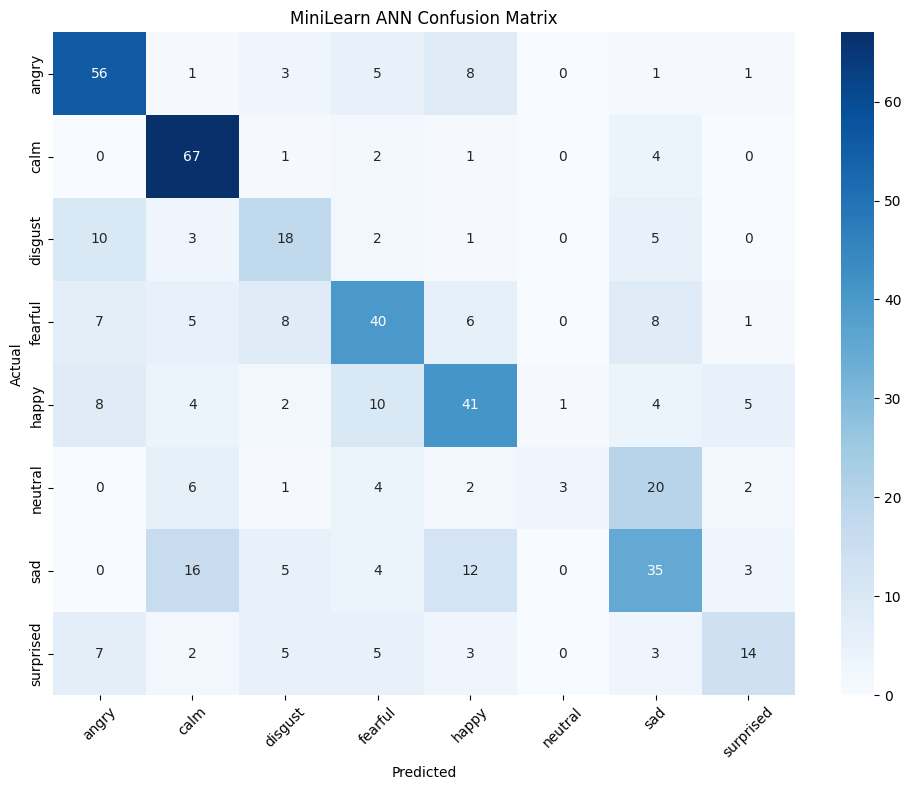

MiniLearn Classification Report
              precision    recall  f1-score   support

       angry       0.64      0.75      0.69        75
        calm       0.64      0.89      0.75        75
     disgust       0.42      0.46      0.44        39
     fearful       0.56      0.53      0.54        75
       happy       0.55      0.55      0.55        75
     neutral       0.75      0.08      0.14        38
         sad       0.44      0.47      0.45        75
   surprised       0.54      0.36      0.43        39

    accuracy                           0.56       491
   macro avg       0.57      0.51      0.50       491
weighted avg       0.57      0.56      0.54       491



In [12]:
#minilearn Ann confusion matrix and report
plt.figure(figsize=(10,8))
cm_mini = confusion_matrix(y_test, mini_ann2_preds, labels=classes)
sns.heatmap(cm_mini, annot=True, fmt='d', cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title('MiniLearn ANN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("MiniLearn Classification Report")
print(classification_report(y_test, mini_ann2_preds))

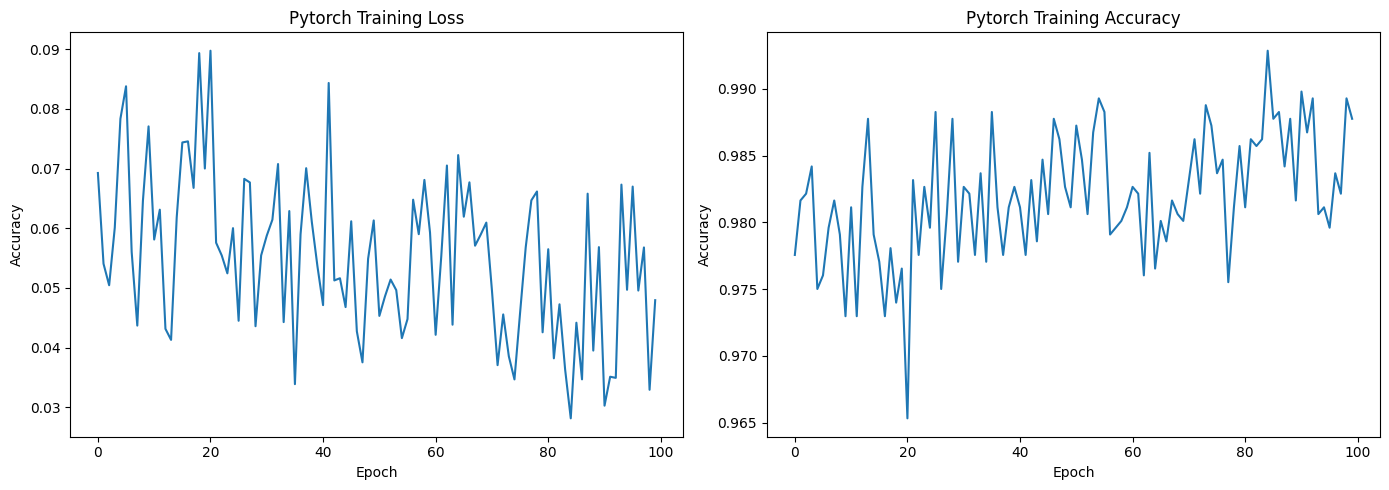

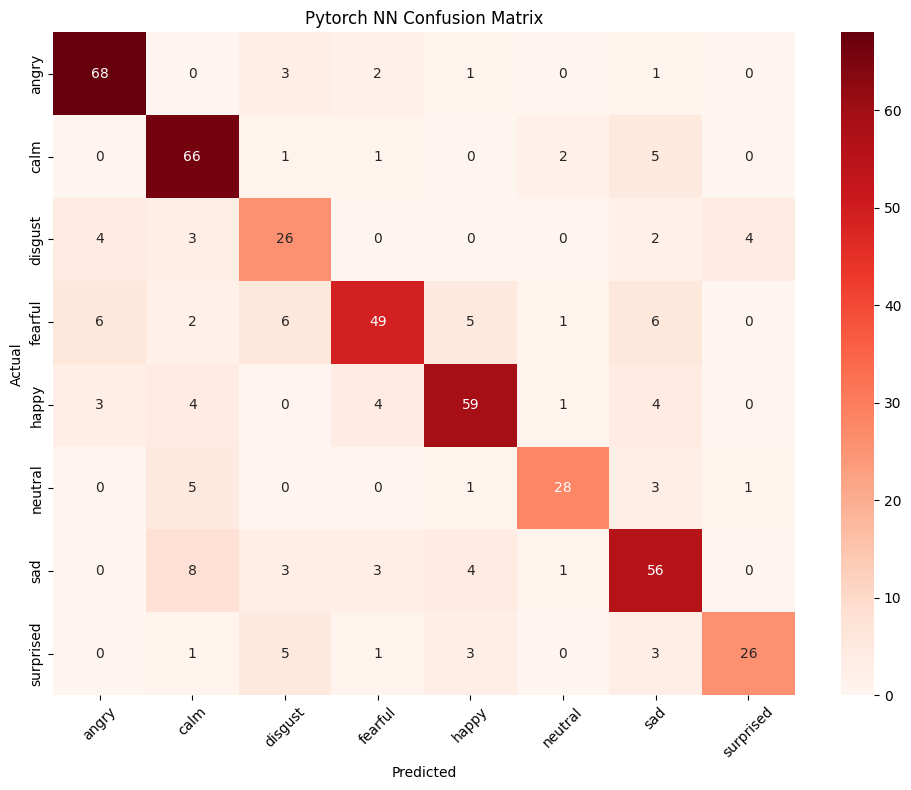

Pytorch Classification Report
              precision    recall  f1-score   support

       angry       0.84      0.91      0.87        75
        calm       0.74      0.88      0.80        75
     disgust       0.59      0.67      0.63        39
     fearful       0.82      0.65      0.73        75
       happy       0.81      0.79      0.80        75
     neutral       0.85      0.74      0.79        38
         sad       0.70      0.75      0.72        75
   surprised       0.84      0.67      0.74        39

    accuracy                           0.77       491
   macro avg       0.77      0.76      0.76       491
weighted avg       0.78      0.77      0.77       491



In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(train_losses)
axes[0].set_title('Pytorch Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel("Accuracy")

axes[1].plot(train_accs)
axes[1].set_title('Pytorch Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

#converting prediction back to emotion labels
pytorch_pred_labels = np.array([classes[idx] for idx in pytorch_preds])

#confusion Matrix
plt.figure(figsize=(10,8))
cm = confusion_matrix(y_test, pytorch_pred_labels, labels=classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=classes, yticklabels=classes)
plt.title('Pytorch NN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Pytorch Classification Report")
print(classification_report(y_test, pytorch_pred_labels))


Week 13 Analysis

I implemented a simple ANN from strach in minilearn and applied a deeper pytorch neural network to the ser task we compared both models against eachother and previous weeks implementations.

MiniLearn
the MiniLearn ANN model implements a single hidden layer with ReLu activation and a soft max output. I first tried 1000 iterations and found it had a output of 39% accuracy this was low so I thought to iterate through the model more. I tried 2000 iterations next and saw it achieved a accuracy of 55.8% confirming my suspisions that it need more time to iterate. I believe that accuracy was lower than the other models because of my simplicy of my ANN. My ANN seemed to struggle with neutral emotion 0.08 but had an amazing recall from calm 0.89.

Pytorch
The pytorch model used a more complex structure with 3 hidden layers, dropout regularization, and a adam optimizer and it achieved a 76.99% test accuracy which is the highest by far. The training accuracy was 98.7% which is way higher than the test accuracy indicating overfitting despite dropout regularizaton. The training loss curve is all over the place with a gerneral decrease overall most likely due to the batch size of 32. and Anger and Clam stay on top of best classified when digust remains the hardest emotion to classify. 

Mini Vs PyTorch
The Pytorch model was significantly better than my Mini which is to be expected with the simplicity of my Mini model. Its most likely due to PyTorchs 3 hidden layer design, adam optimizer, Drop out regulaization, and mini batch training.

NN VS Other Models
Pytoch outpreformed all other models we have implemented including our tued SVM RBF which reigned king for a long time. This really shows the power of deep learning models for complex classification like audio emotion recognition. SVM still handled the large dataset well however. 

Final Ranking:
| 1 | PyTorch Neural Network | 76.99% |
| 2 | Tuned SVM RBF (C=10) | 75.15% |
| 3 | Logistic Regression | 64.52% |
| 4 | Random Forest (Tuned) | 65.09% |
| 5 | KNN k=5 | 55.26% |
| 6 | MiniLearn ANN | 55.80% |
| 7 | AdaBoost | 39.93% |
| 8 | Gaussian Naive Bayes | 38.34% |
| 9 | Decision Tree | 36.50% |

Overall Neural networks outpreform classical models on our dataset, with Pytorch reigning supreme over the others. It was a modest improvement however showing taht careful feature engineering and hyperparameter tuning for non Neural network models can still be competetive on datasets like this. 